# Weather Dataset — Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) of the **Weather** benchmark dataset, loaded through the `lightningnbeats` library.

The Weather dataset (THUML Time-Series-Library) contains 21 meteorological indicators sampled at 10-minute intervals (~52,696 timesteps). By default, `WeatherDataset` drops the `OT` target column and exposes 20 indicator columns in columnar form (rows = timesteps, columns = indicators).

Sections:
1. Data loading
2. Raw data preview & summary statistics
3. Time-series visualization (5 random indicators + longest continuous segment)
4. Heat map across all indicators
5. Correlation analysis between indicators
6. Seasonal decomposition
7. Distribution / normalization check

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from lightningnbeats.data import WeatherDataset

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

## 1. Data Loading

Initialize `WeatherDataset` with a forecast horizon of 96 (a common LTSF benchmark setting). The dataset exposes three chronological splits: `train_data`, `val_data`, and `test_data`. For convenience we alias the training and test splits to `train_df` and `test_df`.

In [2]:
import os
from IPython.display import display

weather = WeatherDataset(horizon=96)

train_df = weather.train_data
val_df   = weather.val_data
test_df  = weather.test_data

# The cached weather.csv uses latin-1 for unit symbols (µ, ²).  Pandas decodes
# it as utf-8 by default, which turns those bytes into U+FFFD replacements.
# Re-read the header with latin-1 and restore the original column names.
if any('\ufffd' in c for c in train_df.columns):
    cache = os.path.join(os.path.expanduser('~'),
                         '.cache', 'lightningnbeats', 'Weather', 'weather.csv')
    clean = pd.read_csv(cache, encoding='latin-1', nrows=0).columns.tolist()
    for drop in ('date', 'OT'):
        if drop in clean:
            clean.remove(drop)
    for frame in (train_df, val_df, test_df):
        frame.columns = clean

n_total = len(train_df) + len(val_df) + len(test_df)

meta = pd.DataFrame({
    'Property': [
        'Dataset name', 'Forecast horizon', 'Seasonal frequency',
        'Total timesteps', 'Num indicators',
        'train_df shape', 'val_df shape', 'test_df shape',
    ],
    'Value': [
        weather.name,
        weather.forecast_length,
        f'{weather.frequency} (10-min samples per day)',
        n_total,
        train_df.shape[1],
        f'{train_df.shape}  ({len(train_df) / n_total:.1%})',
        f'{val_df.shape}  ({len(val_df) / n_total:.1%})',
        f'{test_df.shape}  ({len(test_df) / n_total:.1%})',
    ],
})

left = {'text-align': 'left'}
th_left = [{'selector': 'th', 'props': [('text-align', 'left')]}]

display(meta.style.hide(axis='index')
            .set_properties(**left)
            .set_table_styles(th_left))

# Show the 20 indicator names as the actual columns of a table.
cols_table = pd.DataFrame(
    [train_df.dtypes.astype(str).values],
    index=['dtype'],
    columns=train_df.columns,
)
display(cols_table.style.set_properties(**left).set_table_styles(th_left))

Property,Value
Dataset name,Weather-96
Forecast horizon,96
Seasonal frequency,144 (10-min samples per day)
Total timesteps,52696
Num indicators,20
train_df shape,"(36887, 20) (70.0%)"
val_df shape,"(5269, 20) (10.0%)"
test_df shape,"(10540, 20) (20.0%)"


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/mï¿½),PAR (ï¿½mol/mï¿½/s),max. PAR (ï¿½mol/mï¿½/s),Tlog (degC)
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


## 2. Raw Data Preview & Summary Statistics

A raw dump of the first few rows followed by `.describe()` on the full training frame. Because all 20 indicator columns are numeric, `describe()` reports statistics for every feature.

In [3]:
train_df.head(10)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/mï¿½),PAR (ï¿½mol/mï¿½/s),max. PAR (ï¿½mol/mï¿½/s),Tlog (degC)
0,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,5.42,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81
5,1008.44,0.34,272.84,-1.54,87.1,6.26,5.45,0.81,3.37,5.41,1281.84,0.63,1.32,188.0,0.0,0.0,0.0,0.0,0.0,11.91
6,1008.49,0.19,272.69,-1.65,87.4,6.19,5.41,0.78,3.34,5.37,1282.63,0.88,1.28,195.4,0.0,0.0,0.0,0.0,0.0,12.00
7,1008.40,0.03,272.53,-1.70,88.1,6.12,5.39,0.73,3.33,5.35,1283.30,1.05,1.64,183.1,0.0,0.0,0.0,0.0,0.0,12.07
8,1008.29,0.11,272.63,-1.61,88.1,6.16,5.43,0.73,3.35,5.38,1282.73,0.90,1.72,199.9,0.0,0.0,0.0,0.0,0.0,12.12
9,1008.28,0.22,272.73,-1.62,87.4,6.20,5.42,0.78,3.35,5.38,1282.24,0.62,1.04,123.9,0.0,0.0,0.0,0.0,0.0,12.14


In [4]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
p (mbar),36887.0,990.642462,8.630827,962.08,985.445,991.09,996.040,1020.07
T (degC),36887.0,11.978743,7.718527,-6.44,5.450,11.95,17.850,34.80
Tpot (K),36887.0,285.909500,7.916784,266.19,279.430,286.02,291.890,309.13
Tdew (degC),36887.0,5.474409,6.464493,-13.81,0.400,5.23,10.600,20.50
rh (%),36887.0,67.529991,18.755414,21.16,52.740,69.64,82.750,100.00
VPmax (mbar),36887.0,15.683926,8.109191,3.77,9.010,14.00,20.480,55.67
VPact (mbar),36887.0,9.844447,4.396244,2.09,6.290,8.87,12.800,24.16
VPdef (mbar),36887.0,5.839411,5.902797,0.00,1.740,3.60,8.250,42.10
sh (g/kg),36887.0,6.215719,2.799919,1.30,3.950,5.60,8.080,15.40
H2OC (mmol/mol),36887.0,9.947951,4.461996,2.09,6.330,8.98,12.930,24.53


In [5]:
print('Missing values per column:')
print(train_df.isna().sum())
print(f'\nTotal NaNs in train_df: {int(train_df.isna().sum().sum())}')

Missing values per column:
p (mbar)                    0
T (degC)                    0
Tpot (K)                    0
Tdew (degC)                 0
rh (%)                      0
VPmax (mbar)                0
VPact (mbar)                0
VPdef (mbar)                0
sh (g/kg)                   0
H2OC (mmol/mol)             0
rho (g/m**3)                0
wv (m/s)                    0
max. wv (m/s)               0
wd (deg)                    0
rain (mm)                   0
raining (s)                 0
SWDR (W/mï¿½)               0
PAR (ï¿½mol/mï¿½/s)         0
max. PAR (ï¿½mol/mï¿½/s)    0
Tlog (degC)                 0
dtype: int64

Total NaNs in train_df: 0


## 3. Time-Series Visualization

Each column is a univariate time series. We first plot five randomly selected indicators on a shared axis, then show the longest continuous segment (the full training split) for a single indicator so seasonal and trend structure is visible.

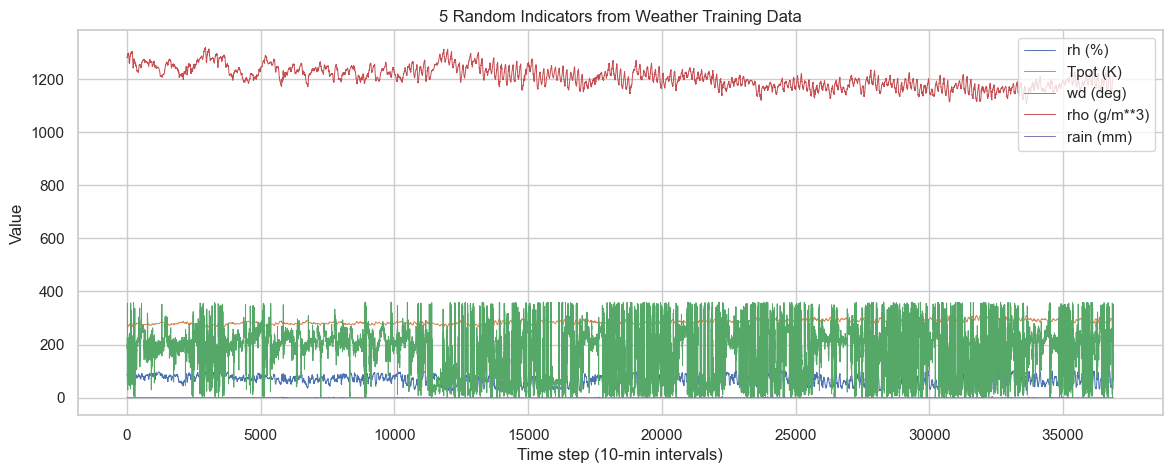

In [6]:
rng = np.random.default_rng(seed=44)
sample_cols = rng.choice(train_df.columns, size=5, replace=False)

plt.figure(figsize=(14, 5))
for col in sample_cols:
    plt.plot(train_df.index, train_df[col], label=col, linewidth=0.7)

plt.title('5 Random Indicators from Weather Training Data')
plt.xlabel('Time step (10-min intervals)')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

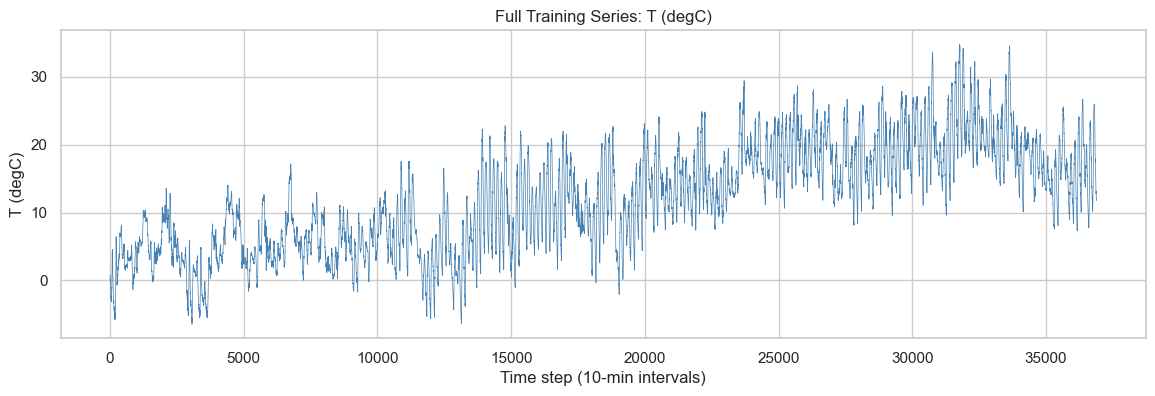

In [7]:
focus_col = 'T (degC)' if 'T (degC)' in train_df.columns else train_df.columns[0]

plt.figure(figsize=(14, 4))
plt.plot(train_df.index, train_df[focus_col], linewidth=0.5, color='steelblue')
plt.title(f'Full Training Series: {focus_col}')
plt.xlabel('Time step (10-min intervals)')
plt.ylabel(focus_col)
plt.grid(True)
plt.show()

## 4. Heat Map Across All Indicators

The heatmap visualizes all 20 indicators simultaneously. Rows are indicators, columns are time steps from a contiguous 1,000-step window, and color encodes the z-scored value so that features with very different native scales can be compared on one axis.

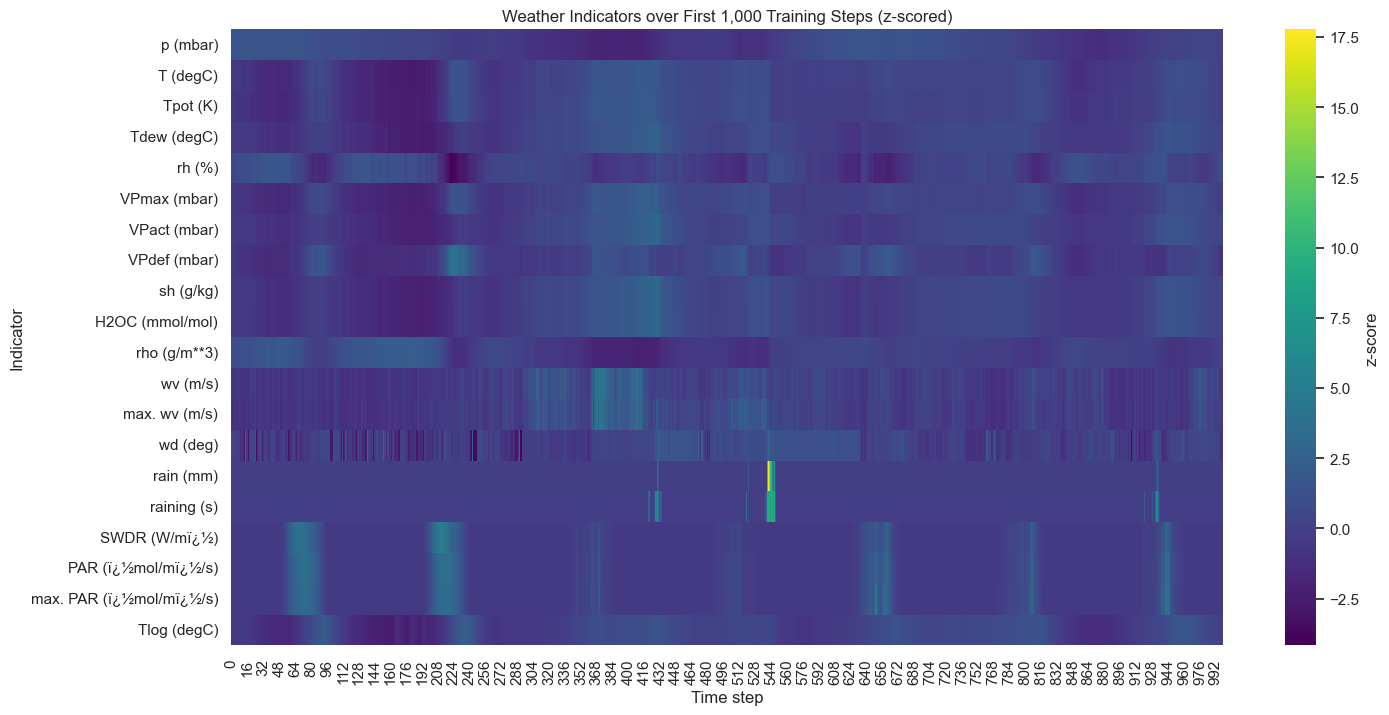

In [8]:
window = train_df.iloc[:1000]
zscored = (window - window.mean()) / window.std().replace(0, 1.0)

plt.figure(figsize=(16, 8))
sns.heatmap(zscored.T, cmap='viridis', cbar_kws={'label': 'z-score'})
plt.title('Weather Indicators over First 1,000 Training Steps (z-scored)')
plt.xlabel('Time step')
plt.ylabel('Indicator')
plt.show()

## 5. Correlation Analysis

Pearson correlation between the 20 indicators on the training split. Strong off-diagonal clusters indicate redundant features (e.g., temperature-related columns) and motivate multivariate modeling choices.

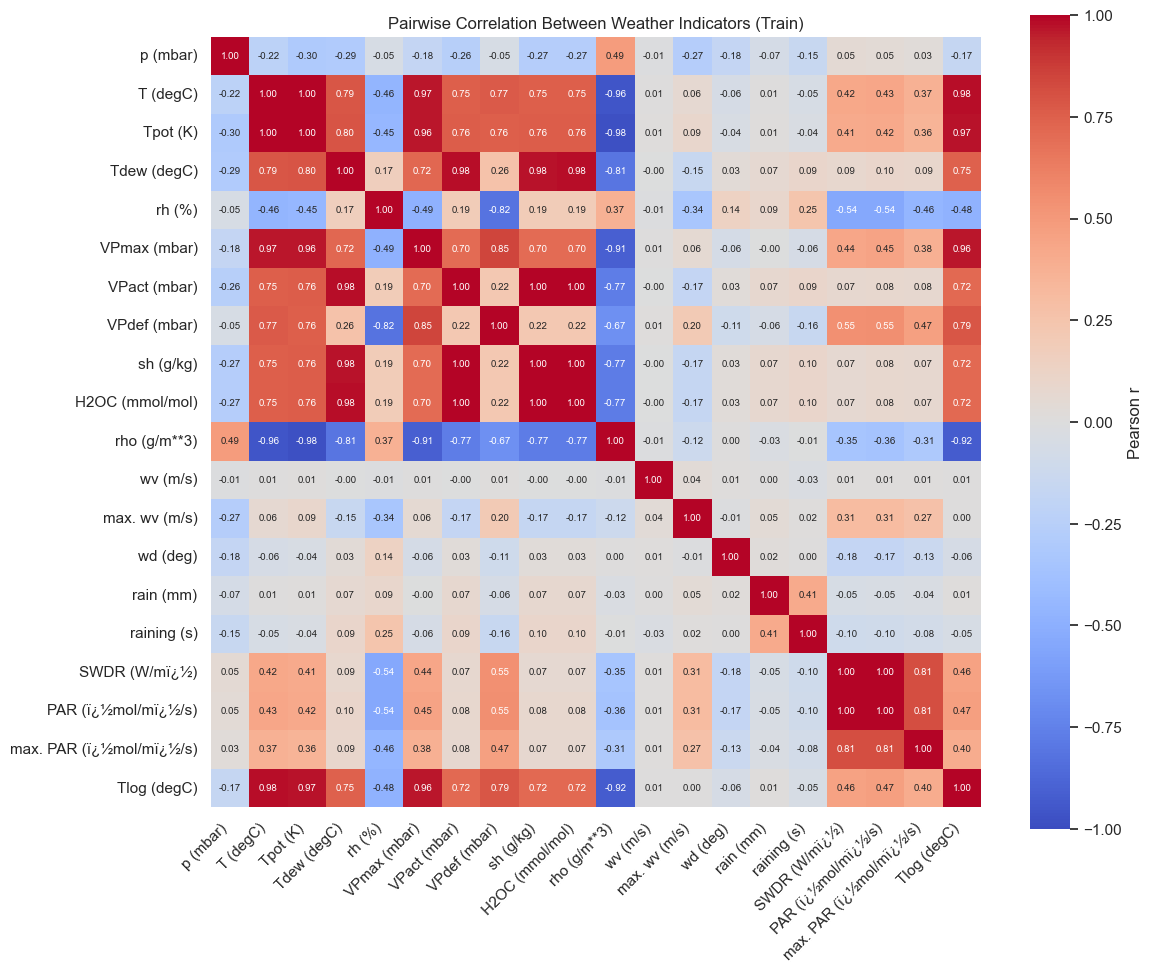

In [9]:
corr = train_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=True,
            fmt='.2f', annot_kws={'size': 7}, square=True,
            cbar_kws={'label': 'Pearson r'})
plt.title('Pairwise Correlation Between Weather Indicators (Train)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Seasonal Decomposition

Apply classical additive decomposition (`statsmodels.tsa.seasonal_decompose`) to a single indicator using the dataset's native seasonal period (`frequency = 144`, one day of 10-minute samples). The decomposition separates the signal into trend, seasonal, and residual components.

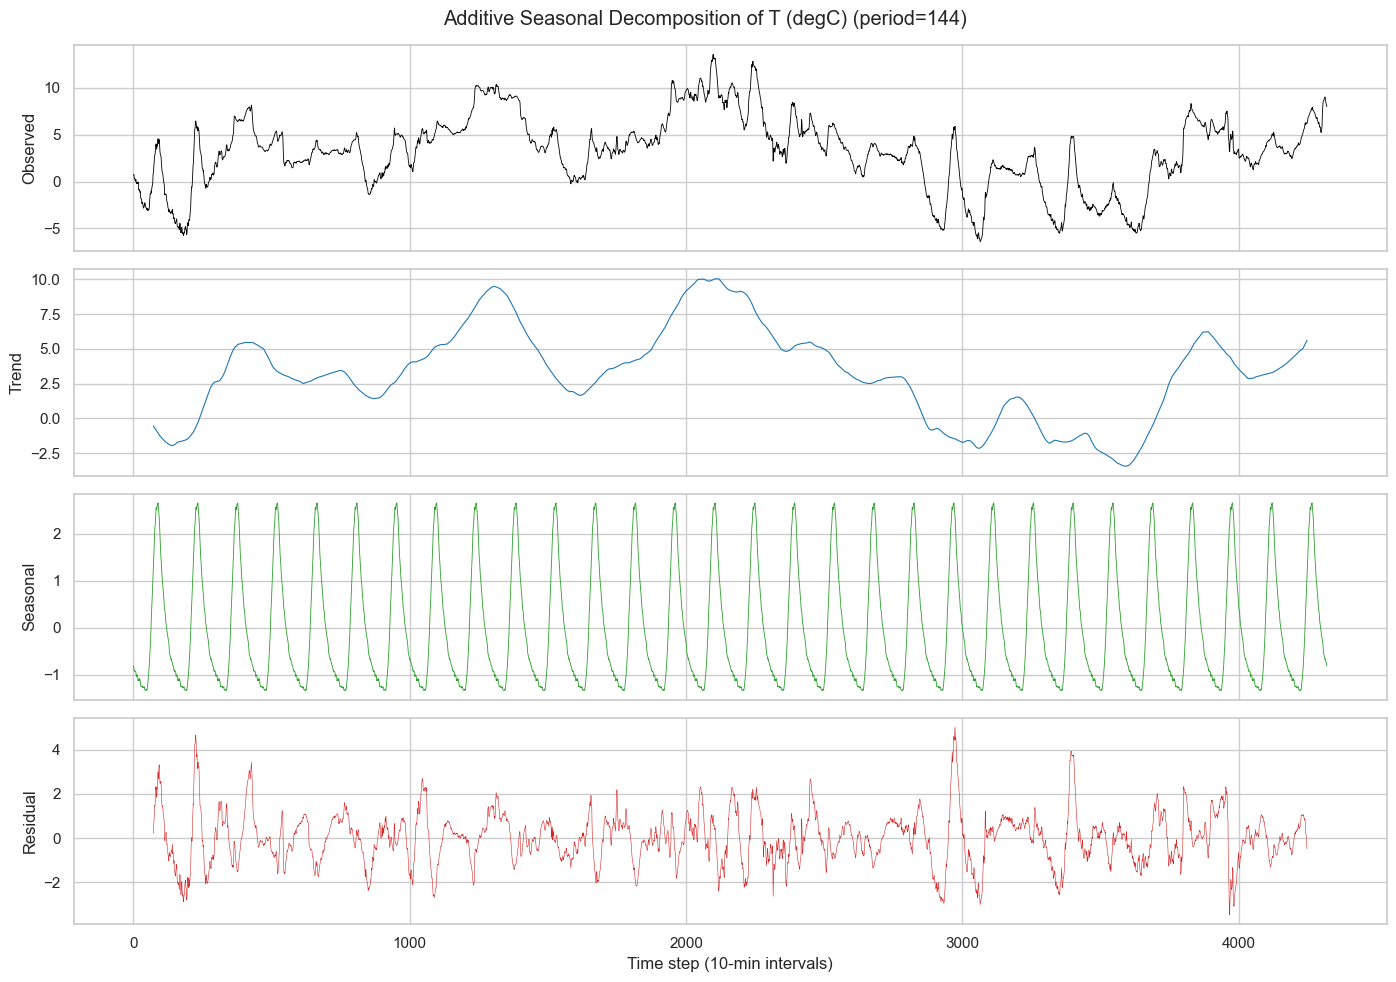

In [10]:
decomp_series = train_df[focus_col].iloc[: 144 * 30]  # ~30 days
decomp = seasonal_decompose(decomp_series, model='additive', period=weather.frequency)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomp.observed, color='black', linewidth=0.6); axes[0].set_ylabel('Observed')
axes[1].plot(decomp.trend,    color='tab:blue',  linewidth=0.8); axes[1].set_ylabel('Trend')
axes[2].plot(decomp.seasonal, color='tab:green', linewidth=0.6); axes[2].set_ylabel('Seasonal')
axes[3].plot(decomp.resid,    color='tab:red',   linewidth=0.4); axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Time step (10-min intervals)')
fig.suptitle(f'Additive Seasonal Decomposition of {focus_col} (period={weather.frequency})')
plt.tight_layout()
plt.show()

## 7. Distribution / Normalization Check

Weather indicators span very different native ranges (e.g., pressure in hPa vs. humidity in %). The histograms below show the marginal distribution of each column, and the boxplot on standardized values summarizes skewness and outliers. Heavy tails and scale mismatches motivate the per-series normalization typically used in LTSF benchmarks.

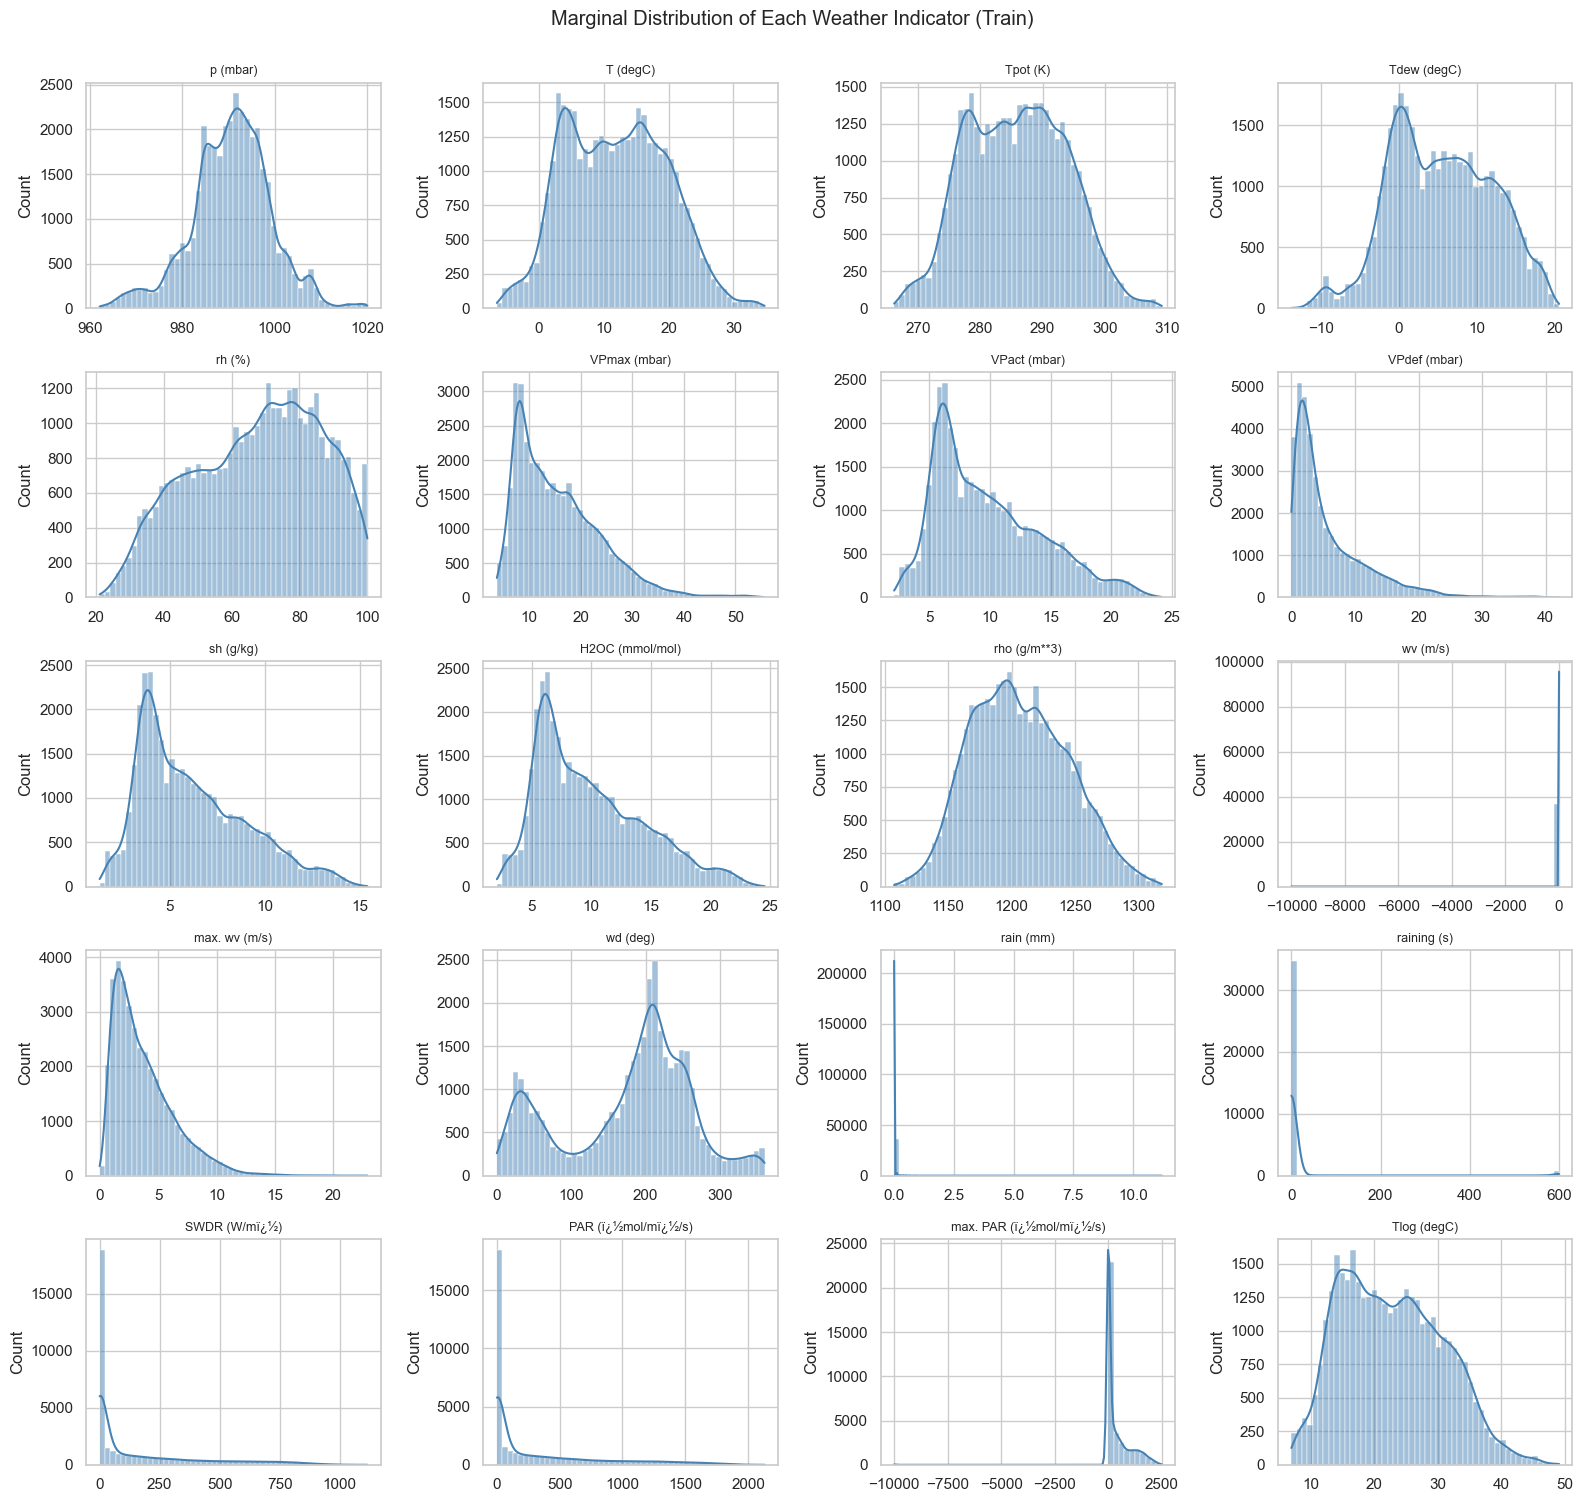

In [11]:
n_cols = len(train_df.columns)
ncols = 4
nrows = int(np.ceil(n_cols / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
axes = axes.flatten()
for ax, col in zip(axes, train_df.columns):
    sns.histplot(train_df[col], bins=50, kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
for ax in axes[n_cols:]:
    ax.set_visible(False)
fig.suptitle('Marginal Distribution of Each Weather Indicator (Train)', y=1.0)
plt.tight_layout()
plt.show()

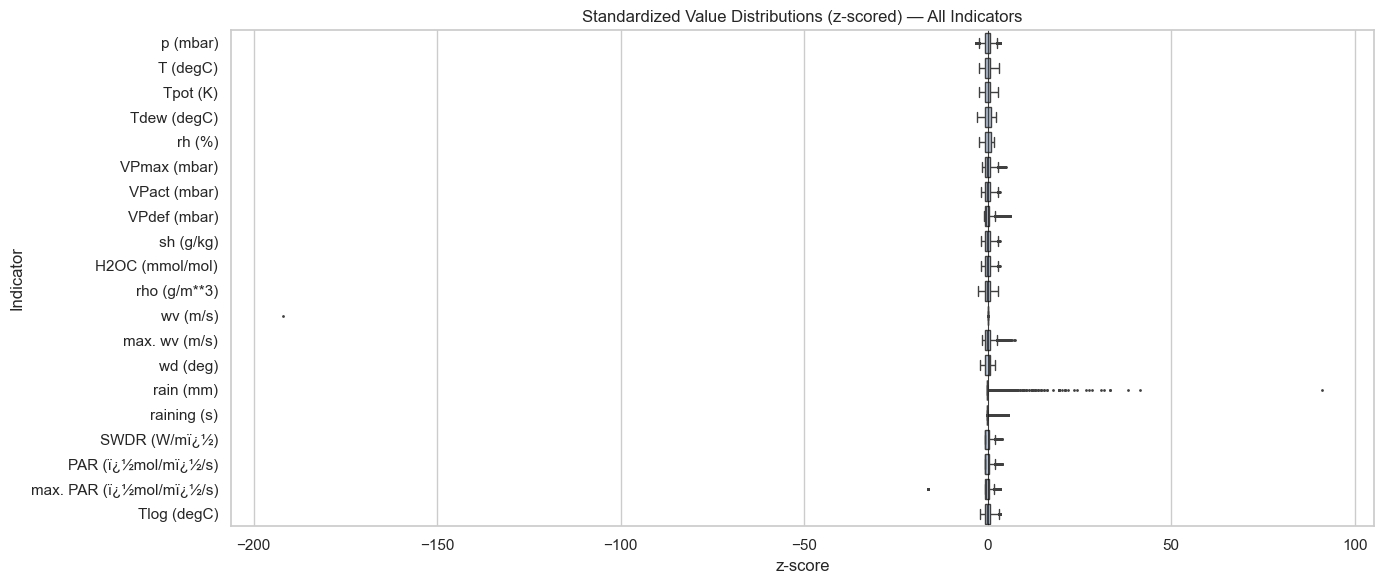

In [12]:
zscored_all = (train_df - train_df.mean()) / train_df.std().replace(0, 1.0)

plt.figure(figsize=(14, 6))
sns.boxplot(data=zscored_all, orient='h', color='lightsteelblue', fliersize=1)
plt.title('Standardized Value Distributions (z-scored) — All Indicators')
plt.xlabel('z-score')
plt.ylabel('Indicator')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()